#### GROUP 17: Shuvojyoti Singha, Artjom Smorgulenko, Kaan Özkiliç, Samuel Pasierb

# Exploring Unsupervised Learning with the k-Means Algorithm

## Dataset Background
> This dataset contains the answers to 60 questions to determine the personality of a person. The possible personalities are: 
*  ESTJ - The Supervisor
*  ENTJ - The Commander 
*  ESFJ - The Provider 
*  ENFJ - The Giver
*  ISTJ - The Inspector
*  ISFJ - The Nurturer 
*  INTJ - The Mastermind
*  INFJ - The Counselor
*  ESTP - The Doer
*  ESFP - The Performer
*  ENTP - The Visionary
*  ENFP - The Champion 
*  ISTP - The Craftsman
*  ISFP - The Composer 
*  INTP - The Thinker 
*  INFP - The Idealist 
> The answers range from -3 to 3 depending on much the person agrees with the statement. -3 means full disagreement and 3 means full agreement. 

## Imports


In [206]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from enum import Enum

## Constants & Variables


In [207]:
class Personality:
    full_name: str
    code: str
    index: int
    colour: tuple[float]
    
    def __init__(self, full_name: str, code: str, index: int, colour: tuple[float]) -> None:
        self.full_name = full_name
        self.code = code
        self.index = index
        self.colour = tuple(colour[i] / 255 for i in range(3))


class Personalities(Enum):
    ESTJ = Personality("The Supervisor", "ESTJ", 0, (233, 30, 99))
    ISTJ = Personality("The Inspector", "ISTJ", 4, (226, 46, 210))
    ESTP = Personality("The Doer", "ESTP", 8, (255, 87, 34))
    ISTP = Personality("The Craftsman", "ISTP", 12, (244, 67, 54))
    ESFP = Personality("The Performer", "ESFP", 9, (255, 152, 0))
    ESFJ = Personality("The Provider", "ESFJ", 2, (121, 85, 72))
    ISFP = Personality("The Composer", "ISFP", 13, (255, 235, 59))
    ISFJ = Personality("The Nurturer", "ISFJ", 5, (255, 193, 7))
    INFP = Personality("The Idealist", "INFP", 15, (205, 220, 57))
    INFJ = Personality("The Counselor", "INFJ", 7, (139, 195, 74))
    ENFP = Personality("The Champion", "ENFP", 11, (0, 150, 136))
    ENFJ = Personality("The Giver", "ENFJ", 3, (76, 175, 80))
    INTJ = Personality("The Mastermind", "INTJ", 6, (156, 39, 176))
    INTP = Personality("The Thinker", "INTP", 14, (0, 188, 212))
    ENTJ = Personality("The Commander", "ENTJ", 1, (63, 81, 181))
    ENTP = Personality("The Visionary", "ENTP", 10, (33, 150, 243))
    

    def from_index(index) -> Personality:
        for personality in Personalities:
            if personality.value.index == index: return personality.value
    

class Question:
    index: int
    text: str
    
    def __init__(self, index, text) -> None:
        self.index = index
        self.text = text
        

questions: list[Question] = []
pca: PCA = PCA(2)

## Loading dataset
This dataset is downloaded from Kaggle. It includeds 62 columns, 1 of them being an ID and 1 the Personality, the rest are questions. There was � in the .csv file which had to be replaced with ' manually.

[The link to the dataset on Kaggle.](https://www.kaggle.com/datasets/anshulmehtakaggl/60k-responses-of-16-personalities-test-mbt)

In [208]:
df: pd.DataFrame = pd.read_csv('personality-test-dataset.csv')
df.head()

,Response Id,You regularly make new friends.,You spend a lot of your free time exploring various random topics that pique your interest,Seeing other people cry can easily make you feel like you want to cry too,You often make a backup plan for a backup plan.,"You usually stay calm, even under a lot of pressure","At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",You prefer to completely finish one project before starting another.,You are very sentimental.,You like to use organizing tools like schedules and lists.,...,You believe that pondering abstract philosophical questions is a waste of time.,"You feel more drawn to places with busy, bustling atmospheres than quiet, intimate places.",You know at first glance how someone is feeling.,You often feel overwhelmed.,You complete things methodically without skipping over any steps.,You are very intrigued by things labeled as controversial.,You would pass along a good opportunity if you thought someone else needed it more.,You struggle with deadlines.,You feel confident that things will work out for you.,Personality
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,-1,0,0,0,0,0,ENFP
1,1,0,0,-2,-3,-1,2,-2,0,3,...,0,-2,0,2,0,-1,-1,-1,3,ISFP
2,2,0,0,2,0,-1,2,0,0,1,...,0,2,0,2,-1,0,1,2,1,INFJ
3,3,0,-1,3,-1,0,0,-2,0,-2,...,0,0,-1,-1,0,1,0,-2,-1,ISTP
4,4,0,0,-1,0,2,-1,-2,0,1,...,0,1,0,2,0,1,-1,2,-1,ENFJ


## Data Cleaning
The missing data is handled and questions are replaced with "Question x" to make the dateset look nicer.

- The missing values are filled with 0.
- ID column is dropped because it is unnecesarry.
- Personiality column (target value) is dropped because it is not needed for clustering
- Questions are replaced with "Question x"

In [209]:
df.fillna(0, inplace=True)
print(df.isnull().sum())

Response Id                                                                                   0
You regularly make new friends.                                                               0
You spend a lot of your free time exploring various random topics that pique your interest    0
Seeing other people cry can easily make you feel like you want to cry too                     0
You often make a backup plan for a backup plan.                                               0
                                                                                             ..
You are very intrigued by things labeled as controversial.                                    0
You would pass along a good opportunity if you thought someone else needed it more.           0
You struggle with deadlines.                                                                  0
You feel confident that things will work out for you.                                         0
Personality                             

In [210]:
correct_personality: pd.Series = df.Personality

if "Response Id" in df.columns: df = df.drop(["Response Id"], axis=1)
if "Personality" in df.columns: df = df.drop(["Personality"], axis=1)

print(df.columns)

Index(['You regularly make new friends.',
       'You spend a lot of your free time exploring various random topics that pique your interest',
       'Seeing other people cry can easily make you feel like you want to cry too',
       'You often make a backup plan for a backup plan.',
       'You usually stay calm, even under a lot of pressure',
       'At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know',
       'You prefer to completely finish one project before starting another.',
       'You are very sentimental.',
       'You like to use organizing tools like schedules and lists.',
       'Even a small mistake can cause you to doubt your overall abilities and knowledge.',
       'You feel comfortable just walking up to someone you find interesting and striking up a conversation.',
       'You are not too interested in discussing various interpretations and analyses of creative works.',
       'You are more inclined to fo

In [211]:
questions = [Question(i + 1, q) for i, q in enumerate(df.columns)]
df.columns = [f"Questions {q.index}" for q in questions]

In [212]:
df.head()

,Questions 1,Questions 2,Questions 3,Questions 4,Questions 5,Questions 6,Questions 7,Questions 8,Questions 9,Questions 10,...,Questions 51,Questions 52,Questions 53,Questions 54,Questions 55,Questions 56,Questions 57,Questions 58,Questions 59,Questions 60
0,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,-1,0,0,0,0,0
1,0,0,-2,-3,-1,2,-2,0,3,0,...,0,0,-2,0,2,0,-1,-1,-1,3
2,0,0,2,0,-1,2,0,0,1,0,...,0,0,2,0,2,-1,0,1,2,1
3,0,-1,3,-1,0,0,-2,0,-2,0,...,0,0,0,-1,-1,0,1,0,-2,-1
4,0,0,-1,0,2,-1,-2,0,1,0,...,0,0,1,0,2,0,1,-1,2,-1


## Algorithm Implementation

### 1. Transforming the data from 60 Dimensions to 2 Dimensions

In [213]:
df = pd.DataFrame(data=pca.fit_transform(df), columns=["A", "B"])
df.head()

# df: pd.DataFrame = pd.DataFrame(np.array(list(np.array([sum(list(filter(lambda x: x > 0, row))), sum(list(filter(lambda x: x < 0, row)))]) for row in df.to_numpy())), columns=["Positive", "Negative"])
# df.head()

,A,B
0,0.369013,-0.309811
1,1.755267,-0.978731
2,3.092429,2.543054
3,0.438875,1.461282
4,-3.332690,0.946856


### 2. Run k-Means Algorithm

In [214]:
km = KMeans(n_clusters=16)
clusters: np.ndarray = km.fit_predict(df)
df["Personality"] = clusters

c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


### 3. Divide the dataframe into 16 dataframes based on personalities for visualization

In [215]:
dataframes: list[pd.DataFrame] = []

for personality in Personalities:
    dataframes.append(df[df.Personality == personality.value.index])

## Visualization

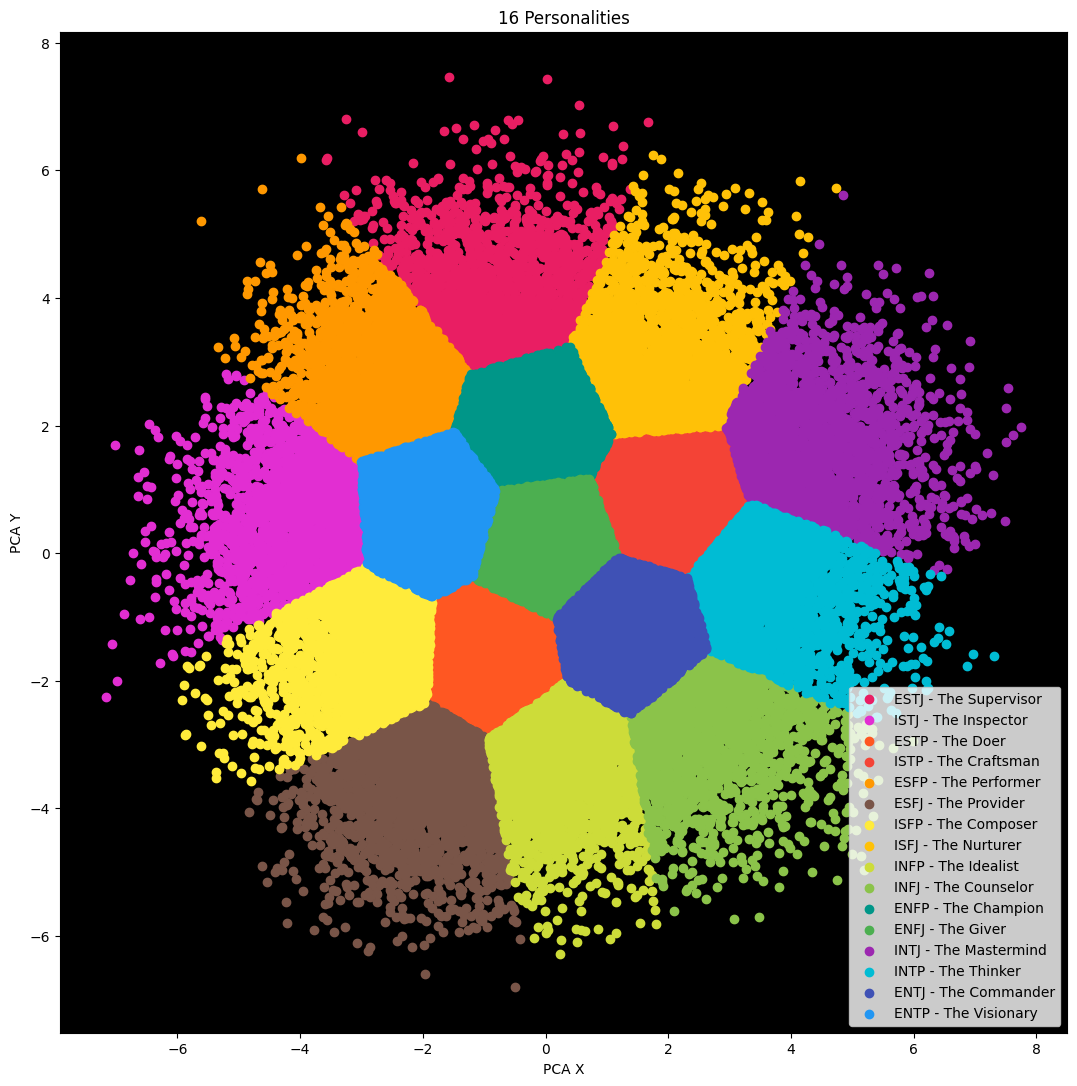

In [216]:
plt.figure(figsize=(13, 13))

for dataframe in dataframes:
    if len(dataframe) == 0: continue
    personality: Personality = Personalities.from_index(dataframe.Personality.values[0])
    plt.scatter(dataframe["A"], dataframe["B"], c=[personality.colour], label=f"{personality.code} - {personality.full_name}")

plt.title("16 Personalities")
plt.ylabel("PCA Y")
plt.xlabel("PCA X")
plt.gca().set_facecolor("black")
plt.legend()
plt.show()